# Setup
___

## Imports

In [5]:
import requests
import pandas as pd
import json
import time
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


## Loading in API tokens

In [18]:
with open("Strava_Auth.json") as f:
    data = json.load(f)

ACCESS_TOKEN = data["access_token"]
REFRESH_TOKEN = data["refresh_token"]
EXPIRES_AT = data["expires_at"]

CLIENT_ID = 184366
CLIENT_SECRET = "9d947a700de5d67f6d69e8da57dc3b97289326ab"

# Functions
___

### Api token refresh function

In [11]:
def get_access_token():
    global ACCESS_TOKEN, REFRESH_TOKEN, EXPIRES_AT

    # If the token is still valid, return it
    if time.time() < EXPIRES_AT:
        return ACCESS_TOKEN

    # Otherwise, refresh it
    print("🔄 Refreshing Strava access token")

    response = requests.post(
        "https://www.strava.com/api/v3/oauth/token",
        data={
            "client_id": CLIENT_ID,
            "client_secret": CLIENT_SECRET,
            "grant_type": "refresh_token",
            "refresh_token": REFRESH_TOKEN
        }
    ).json()

    ACCESS_TOKEN = response["access_token"]
    REFRESH_TOKEN = response["refresh_token"]
    EXPIRES_AT = response["expires_at"]

    # Optional: save to file so tokens persist between runs
    with open("Strava_Auth.json", "w") as f:
        import json
        json.dump({
            "access_token": ACCESS_TOKEN,
            "refresh_token": REFRESH_TOKEN,
            "expires_at": EXPIRES_AT
        }, f, indent=2)

    return ACCESS_TOKEN

### Getting data from an activity id

In [12]:
def get_data(activity_id):
    token = get_access_token()
    headers = {"Authorization": f"Bearer {token}"}

    url = f"https://www.strava.com/api/v3/activities/{activity_id}/streams"
    params = {"keys": "latlng,time", "key_by_type": "true"}

    data_request = requests.get(url, headers=headers, params=params)
    data_request.raise_for_status()
    return data_request.json()


### Getting Segments Within Bounds

In [13]:
def segments_in_bounds(bounds):
    token = get_access_token()
    headers = {"Authorization": f"Bearer {token}"}

    url = "https://www.strava.com/api/v3/segments/explore"
    params = {
        "bounds": f"{bounds[1]},{bounds[0]},{bounds[3]},{bounds[2]}",
        "activity_type": "running",     # or running/hiking/etc.
        "min_cat": 0,
        "max_cat": 5
    }

    r = requests.get(url, headers=headers, params=params)
    r.raise_for_status()
    return r.json()["segments"]

### Getting effort ID's from segment

In [32]:
def get_segment_efforts(segment_id, page=1):
    token = get_access_token()
    headers = {"Authorization": f"Bearer {token}"}

    url = f"https://www.strava.com/api/v3/segment_efforts/{segment_id}/streams"
    params = {"page": page, "per_page": 200}

    r = requests.get(url, headers=headers, params=params)
    r.raise_for_status()
    return r.json()

# Processing

## Aquiring the Segment ID's

In [7]:
bp_mask = gpd.read_file("../Data/Banks_Merged.shp")
BP_Bounds_meter = bp_mask.total_bounds
BP_Bounds_degree = bp_mask.to_crs(epsg=4326).total_bounds

In [8]:
segment_ids = []
grids = 10
bounds = BP_Bounds_degree.copy()
for lon in range(grids):
    bounds[0] = BP_Bounds_degree[0] + (lon/grids)*(BP_Bounds_degree[2]-BP_Bounds_degree[0])
    bounds[2] = BP_Bounds_degree[0] + ((lon+1)/grids)*(BP_Bounds_degree[2]-BP_Bounds_degree[0])
    for lat in range(grids):
        bounds[1] = BP_Bounds_degree[1] + (lat/grids)*(BP_Bounds_degree[3]-BP_Bounds_degree[1])
        bounds[3] = BP_Bounds_degree[1] + ((lat+1)/grids)*(BP_Bounds_degree[3]-BP_Bounds_degree[1])
        print(f"Processing long {lon+1}/{grids} lat {lat+1}/{grids} with bounds {bounds}")
        segments = segments_in_bounds(bounds)
        for segment in segments:
            segment_ids.append(segment["id"])

Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.90167268 172.47014224 -43.86782302]
🔄 Refreshing Strava access token
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.86782302 172.47014224 -43.83397335]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.83397335 172.47014224 -43.80012369]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.80012369 172.47014224 -43.76627402]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.76627402 172.47014224 -43.73242436]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.73242436 172.47014224 -43.69857469]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.69857469 172.47014224 -43.66472503]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.66472503 172.47014224 -43.63087536]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.63087536 172.47014224 -43.5970257 ]
Processing long 1/10 lat 1/10 with bounds [172.39679568 -43.5970257  172.47014224 -43.56317603]
Process

In [9]:
print(len(segment_ids))
unique_segment_ids = set(segment_ids)
print(len(unique_segment_ids))
segment_ids

283
283


[14727153,
 24031764,
 23378548,
 19344440,
 19344454,
 23378569,
 35790974,
 30671066,
 32314077,
 24031788,
 33687934,
 34036424,
 34853726,
 23345604,
 20862036,
 22547746,
 30980936,
 34036387,
 34036392,
 34418309,
 36242163,
 7184801,
 18378028,
 25557179,
 17033073,
 23407506,
 11666848,
 16063168,
 22790434,
 13612467,
 13611744,
 22790425,
 12180421,
 7093339,
 16569634,
 11907615,
 14127018,
 14126999,
 7367776,
 14127025,
 29527478,
 33556340,
 34219420,
 21133296,
 25414337,
 22465477,
 5795432,
 22465481,
 26683572,
 12598577,
 18484458,
 13440766,
 8182606,
 20814151,
 12515374,
 17966044,
 29057976,
 6016271,
 18102340,
 11175592,
 6016272,
 19090516,
 33446275,
 9231022,
 13554384,
 7833833,
 9231033,
 17340023,
 13562340,
 31635420,
 36168678,
 33903518,
 36168686,
 22639371,
 2214274,
 22460069,
 983594,
 11321845,
 21789000,
 3595386,
 1598342,
 10031598,
 23359679,
 23460815,
 4177475,
 13515211,
 20229083,
 4177486,
 23964126,
 26928159,
 16670794,
 26866223,
 2346

In [ ]:
with open("Segment_IDs.txt", "w") as file:
    for item in segment_ids:
        file.write(f"{item}\n")

## Aquiring the Activity ID's

In [16]:
with open("Segment_IDs.txt", "r") as file:
    segment_id = file.readlines()
    segment_ids = [line.strip() for line in segment_id]

In [34]:
print(get_segment_efforts(segment_ids[0]))

HTTPError: 403 Client Error: Forbidden for url: https://www.strava.com/api/v3/segment_efforts/14727153/streams?page=1&per_page=200

## Aquiring Data From Activity ID's

In [20]:

# Your list of activity IDs
ids = [259999299, 16316332905,4557060872]

# Empty list to collect all activity data
all_activities = []

for id in ids:
    try:
        data = get_data(id)
        latlng = data["latlng"]["data"]
        times = data["time"]["data"]

        # Combine each coordinate/time with the activity id
        for (lat, lng), t in zip(latlng, times):
            all_activities.append({
                "id": id,
                "lat": lat,
                "lng": lng,
                "time": t
            })

        print(f"✅ Got {len(times)} points from activity {id}")

    except requests.HTTPError as e:
        print(f"❌ Failed for activity {id}: {e}")

# Create DataFrame
df = pd.DataFrame(all_activities)

✅ Got 4199 points from activity 259999299
✅ Got 16455 points from activity 16316332905
✅ Got 9923 points from activity 4557060872


# Post Processing

In [100]:
 # Group by polyline_id and create LineString from coordinates
# The 'geometry' column will store the LineString objects
gdf_lines = df.groupby('id').apply(
    lambda x: LineString(zip(x['lng'], x['lat']))
).reset_index(name='geometry')

C:\Users\maxwe\AppData\Local\Temp\ipykernel_9476\619219008.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gdf_lines = df.groupby('id').apply(


In [101]:
geodf_polylines = gpd.GeoDataFrame(gdf_lines, geometry='geometry', crs="EPSG:4326")
geodf_polylines.to_crs(epsg=2193, inplace=True)
geodf_polylines.head()

,id,geometry
0,259999299,"LINESTRING (1579020.376 5169730.259, 1579030.0..."
1,4557060872,"LINESTRING (1596144.297 5148660.257, 1596147.1..."
2,16316332905,"LINESTRING (1568655.475 5176938.494, 1568659.4..."


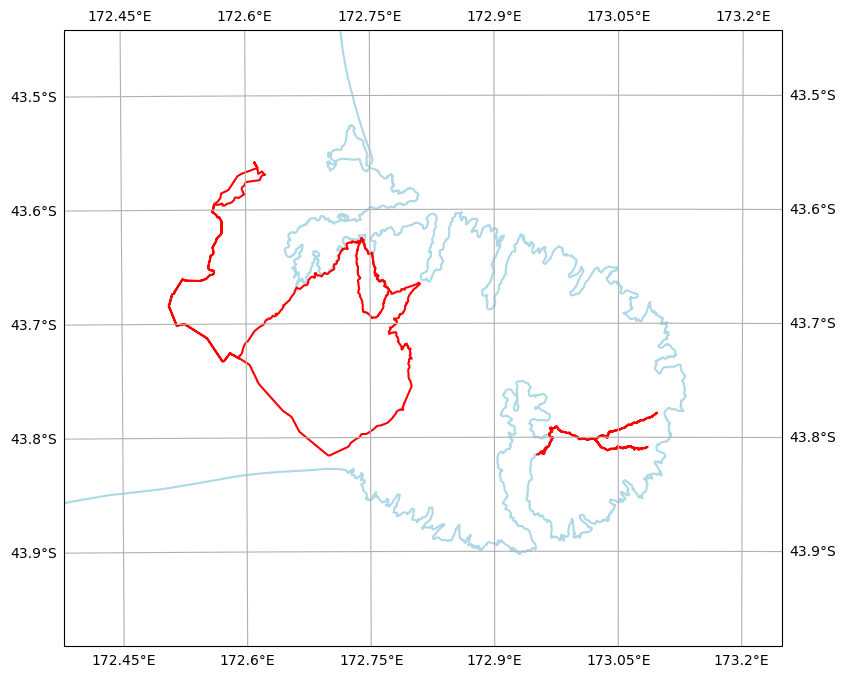

In [102]:

# (Optional) Load your own GeoDataFrame to overlay
# my_data = gpd.read_file("path/to/your/data.shp")

# Create a figure and axes with a Cartopy projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(2193))

coast = gpd.read_file("C:/Users/maxwe/OneDrive/Documents/Uni_Files/Masters/Data/lds-nz-coastlines-topo-150k-SHP/nz-coastlines-topo-150k.shp")

# Add natural earth coastlines
coast = coast.to_crs(epsg=2193)
coast.plot(ax=ax, color='lightblue')

# (Optional) Plot your GeoDataFrame on top of the coastlines
geodf_polylines.plot(ax=ax, transform=ccrs.epsg(2193), color='red', markersize=5)

# Set an extent if needed (e.g., to focus on a region)
ax.set_extent([1550000, 1620000, 5130000, 5190000], crs=ccrs.epsg(2193))

# Add gridlines and labels
ax.gridlines(draw_labels=True)

# Show the plot
plt.show()